# Purpose to clean the dataset and understand the patterns
---
## Data Investigation

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
df = pd.read_csv("../data/raw_data/WELFake_Dataset.csv")
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [15]:
df.tail()

,Unnamed: 0,title,text,label
72129,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0
72133,72133,Goldman Sachs Endorses Hillary Clinton For Pre...,Goldman Sachs Endorses Hillary Clinton For Pre...,1


In [16]:
df.shape

(72134, 4)

In [17]:
for column in df.columns:
    print(f"\n{'='*50}")
    print(f"COLUMN: {column}")
    print(f"{'='*50}")
    print(df[column].head(3))


COLUMN: Unnamed: 0
0    0
1    1
2    2
Name: Unnamed: 0, dtype: int64

COLUMN: title
0    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1                                                  NaN
2    UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
Name: title, dtype: object

COLUMN: text
0    No comment is expected from Barack Obama Membe...
1       Did they post their votes for Hillary already?
2     Now, most of the demonstrators gathered last ...
Name: text, dtype: object

COLUMN: label
0    1
1    1
2    1
Name: label, dtype: int64


In [18]:
df.dtypes

Unnamed: 0     int64
title         object
text          object
label          int64
dtype: object

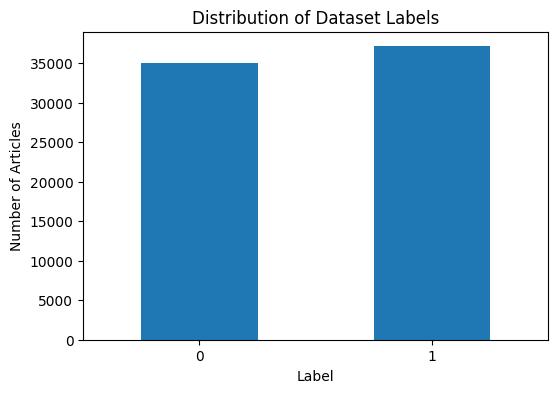

In [20]:
plt.figure(figsize=(6, 4))

df["label"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of Dataset Labels")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)

plt.show()

In [21]:
missing_counts = df.isna().sum()

missing_percentages = (
    df.isna().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percentages
})

missing_summary

,Missing Count,Missing Percentage
Unnamed: 0,0,0.00
title,558,0.77
text,39,0.05
label,0,0.00


In [22]:
if "title" in df.columns:
    duplicate_titles = df["title"].duplicated().sum()

    print(f"Duplicate titles: {duplicate_titles:,}")

Duplicate titles: 9,786


In [23]:
if "text" in df.columns and "label" in df.columns:

    label_variation = (
        df.groupby("text")["label"]
        .nunique()
        .sort_values(ascending=False)
    )

    conflicting_articles = label_variation[
        label_variation > 1
    ]

    print(
        "Articles appearing with multiple labels:",
        len(conflicting_articles)
    )

Articles appearing with multiple labels: 1


Article Length Statistics:


count    72134.000000
mean       540.550933
std        625.399748
min          0.000000
25%        227.000000
50%        398.000000
75%        667.000000
max      24234.000000
Name: text_word_count, dtype: float64


Article Length by Label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,35028.0,577.615536,563.115638,0.0,241.0,427.0,783.0,14641.0
1,37106.0,505.562012,677.121991,0.0,217.0,369.0,568.0,24234.0


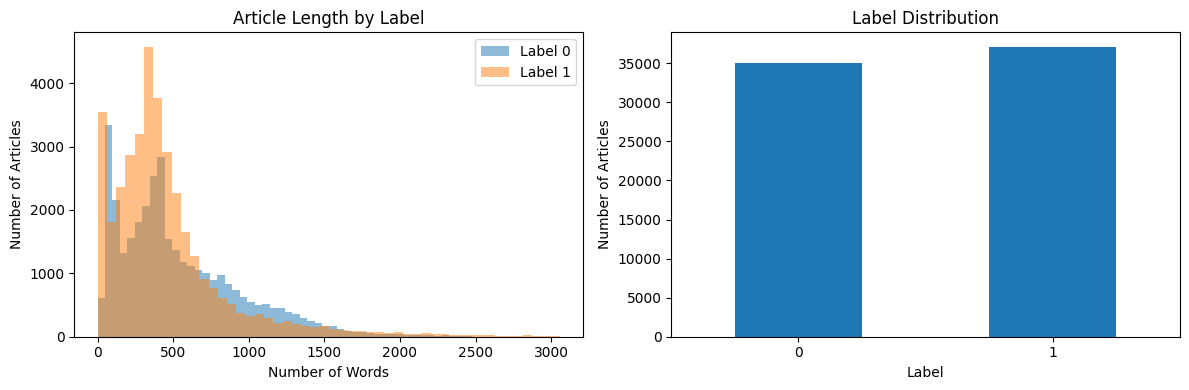

In [25]:
# Article length + label visualization

df["text_char_count"] = df["text"].fillna("").astype(str).str.len()
df["text_word_count"] = df["text"].fillna("").astype(str).str.split().str.len()

print("Article Length Statistics:")
display(df["text_word_count"].describe())

print("\nArticle Length by Label:")
display(df.groupby("label")["text_word_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Article length
for label in sorted(df["label"].dropna().unique()):
    data = df.loc[df["label"] == label, "text_word_count"]
    data = data[data <= data.quantile(0.99)]
    axes[0].hist(data, bins=50, alpha=0.5, label=f"Label {label}")

axes[0].set_title("Article Length by Label")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Number of Articles")
axes[0].legend()

# Label distribution
df["label"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Number of Articles")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()